# 이미지 분류

### 데이터 전처리

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


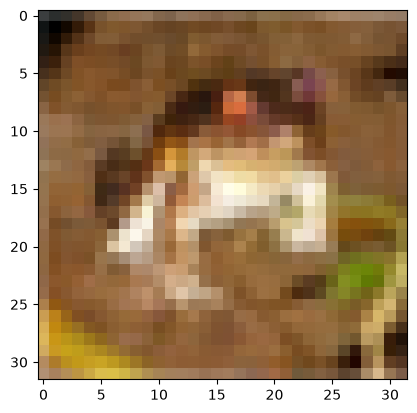

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

import pickle

## 이미지 데이터를 파일로 부터 읽어오는 함수
def unpickle(file):
    with open(file,'rb') as ff:
        data = pickle.load(ff, encoding='bytes')
    return data

## 이미지데이터 <- 파일
batch = unpickle("../fff/cifar-10-batches-py/data_batch_1")

print(batch.keys())

## 이미지들
images = batch[b'data']

#print(images.shape)  ## (10000, 3072)  10000장 이미지  3072 데이터 : 32*32*3

import numpy as np
import matplotlib.pyplot as plt

## 이미지1개 추출
imgOne = images[0]
imgOne = imgOne.reshape(3,32,32)
#imgOne

imgOne = np.transpose(imgOne,(1,2,0)) # 32,32,3 형태로 변경

## 이미지 그리
plt.imshow(imgOne)
plt.show()





In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

import pickle

## 이미지 데이터를 파일로 부터 읽어오는 함수
def unpickle(file):
    with open(file,'rb') as ff:
        data = pickle.load(ff, encoding='bytes')
    return data
#--------------------------------------------
## 학습 데이터 만들기
#--------------------------------------------
train_images=[]     #이미지들
train_labels=[]     #이미지이름들

for i in range(1,6):
    batch = unpickle(f"../fff/cifar-10-batches-py/data_batch_{i}")
    train_images.append(batch[b'data'])
    train_labels.extend(batch[b'labels'])
    
#train_images
#train_labels
    
##5개 파일로 나누어서 들어간 배열들을 붙이기    
## []원소10000 개 배열 * 5  ==> [] 원소 50000 개
train_images=np.concatenate(train_images)    
train_labels=np.array(train_labels)    
print(train_labels)
#train_images.shape  #(50000, 3072)
## 모양바꾸기 (이미지 형태로 변환)
train_images = train_images.reshape(-1,3,32,32) # (50000, 3, 32, 32)
train_images = np.transpose(train_images,(0,2,3,1)) # (50000, 32, 32, 3)
#train_images.shape



#--------------------------------------------
## 테스트 데이터 만들기
#--------------------------------------------
batch = unpickle(f"../fff/cifar-10-batches-py/test_batch")
test_images=batch[b'data']
test_labels=np.array(batch[b'labels']) 

## 모양바꾸기 (이미지 형태로 변환)
test_images = test_images.reshape(-1,3,32,32) # (10000, 3, 32, 32)
test_images = np.transpose(test_images,(0,2,3,1)) # (10000, 32, 32, 3)
test_images


[6 9 9 ... 9 1 1]


array([[[[158, 112,  49],
         [159, 111,  47],
         [165, 116,  51],
         ...,
         [137,  95,  36],
         [126,  91,  36],
         [116,  85,  33]],

        [[152, 112,  51],
         [151, 110,  40],
         [159, 114,  45],
         ...,
         [136,  95,  31],
         [125,  91,  32],
         [119,  88,  34]],

        [[151, 110,  47],
         [151, 109,  33],
         [158, 111,  36],
         ...,
         [139,  98,  34],
         [130,  95,  34],
         [120,  89,  33]],

        ...,

        [[ 68, 124, 177],
         [ 42, 100, 148],
         [ 31,  88, 137],
         ...,
         [ 38,  97, 146],
         [ 13,  64, 108],
         [ 40,  85, 127]],

        [[ 61, 116, 168],
         [ 49, 102, 148],
         [ 35,  85, 132],
         ...,
         [ 26,  82, 130],
         [ 29,  82, 126],
         [ 20,  64, 107]],

        [[ 54, 107, 160],
         [ 56, 105, 149],
         [ 45,  89, 132],
         ...,
         [ 24,  77, 124],
        